# Taxi Order Forecasting

The company "Chyotenkoye Taxi" has collected historical data on taxi orders at airports. To attract more drivers during the peak load period, we need to forecast the number of taxi orders for the next hour.

The target metric — **RMSE** on the test set — must be no more than **48**. The test set is 10% of the source data.

## Research Plan

1) Loading the data and resampling by one hour
2) Exploratory data analysis (trend and seasonality)
3) Feature engineering
4) Correlation analysis of the features
5) Training models and hyperparameter search
6) Testing the best model
7) Overall conclusion

## Installing Dependencies

Before running, I install the required versions of the libraries so that the notebook runs in any environment (including one where scikit-learn is old and does not yet have `SplineTransformer` and `TargetEncoder`).

In [1]:
!pip install -q -U scikit-learn category_encoders phik statsmodels

## Loading the Data

### Importing Modules

In [2]:
import os
import sys
import importlib.abc
import importlib.util
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')


class _MatplotlibCbookPatchFinder(importlib.abc.MetaPathFinder):
    def find_spec(self, fullname, path=None, target=None):
        if fullname != 'matplotlib.cbook' or path is None:
            return None
        for base in path:
            candidate = Path(base) / 'cbook.py'
            if candidate.exists():
                return importlib.util.spec_from_file_location(fullname, candidate)
        return None


sys.meta_path.insert(0, _MatplotlibCbookPatchFinder())

import pandas as pd
import numpy as np
import time
from matplotlib import pyplot as plt
import matplotlib.cm as _matplotlib_cm
if not hasattr(_matplotlib_cm, 'register_cmap'):
    def _register_cmap(name=None, cmap=None, **kwargs):
        return None
    _matplotlib_cm.register_cmap = _register_cmap
import seaborn as sns
import phik
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
    TargetEncoder,
    SplineTransformer,
    PolynomialFeatures,
)
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['image.cmap'] = 'viridis'


### Defining Constants

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.1
VALID_SIZE = 0.2
MAX_RMSE = 48
MAX_LAG = 168
ROLLING_SIZE = 168


Let us load the data and immediately convert the date column into an index of type `datetime`.

In [4]:
try:
    data = pd.read_csv('./source/taxi.csv', index_col=[0], parse_dates=[0])
except FileNotFoundError:
    data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

data = data.sort_index()
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


The data covers the period from March to August 2018, the observation step is 10 minutes. Let us check that the index is monotonically increasing and make sure there are no missing values.

In [5]:
print('Index is monotonically increasing:', data.index.is_monotonic_increasing)
print('Period:', data.index.min(), '—', data.index.max())
print('Missing values:', data['num_orders'].isna().sum())

Index is monotonically increasing: True
Period: 2018-03-01 00:00:00 — 2018-08-31 23:50:00
Missing values: 0


The index is ordered and contains no missing values. As required by the task, we resample the data by one hour — we sum the number of orders within each hour.

In [6]:
data = data.resample('1H').sum()
ts_hourly = data['num_orders'].copy()
print('Shape after resampling:', data.shape)
data.head()


Shape after resampling: (4416, 1)


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


After resampling we obtained 4416 hourly observations with no missing values. We move on to the analysis.

## Exploratory Data Analysis

Let us plot the whole time series.

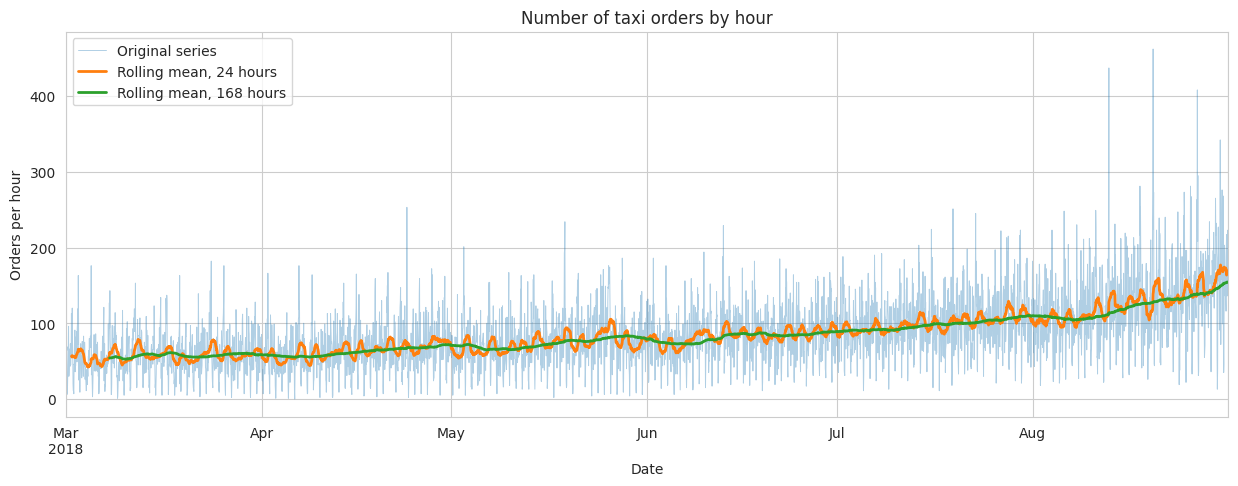

In [7]:
plt.figure(figsize=(15, 5))
data['num_orders'].plot(label='Original series', linewidth=0.7, alpha=0.35)
data['num_orders'].rolling(24).mean().plot(label='Rolling mean, 24 hours', linewidth=2)
data['num_orders'].rolling(168).mean().plot(label='Rolling mean, 168 hours', linewidth=2)
plt.title('Number of taxi orders by hour')
plt.xlabel('Date')
plt.ylabel('Orders per hour')
plt.legend()
plt.grid(True)
plt.show()


An upward trend is noticeable on the chart: over time there are more orders. The daily rolling mean smooths out the noise within the day, while the weekly one shows a smoother growth of the level of the series. A high-frequency oscillating pattern is also visible — probably daily seasonality. Let us look at the descriptive statistics.


In [8]:
data['num_orders'].describe()

count    4416.000000
mean       84.422781
std        45.023853
min         0.000000
25%        54.000000
50%        78.000000
75%       107.000000
max       462.000000
Name: num_orders, dtype: float64

On average about 84 orders arrive per hour, the maximum is 462. To make out the daily and weekly seasonality, let us look at the series over two weeks.

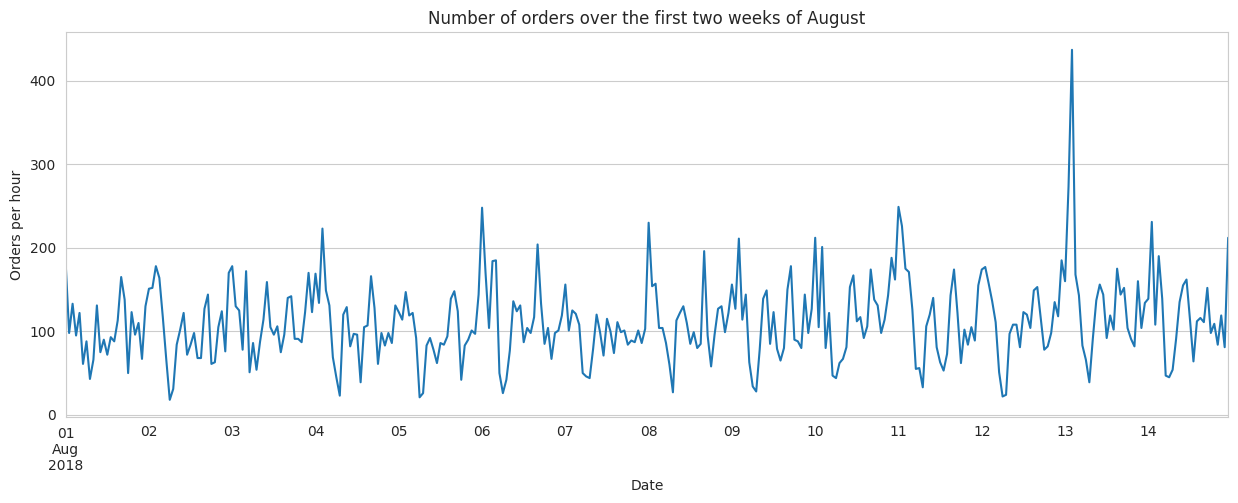

In [9]:
plt.figure(figsize=(15, 5))
data['num_orders']['2018-08-01':'2018-08-14'].plot()
plt.title('Number of orders over the first two weeks of August')
plt.xlabel('Date')
plt.ylabel('Orders per hour')
plt.show()

A pronounced daily seasonality is visible: at night the number of orders is at a minimum, during the day there is growth with peaks. A weekly rhythm can also be discerned. Let us decompose the series into trend, seasonality and residuals with a daily period (24 hours).

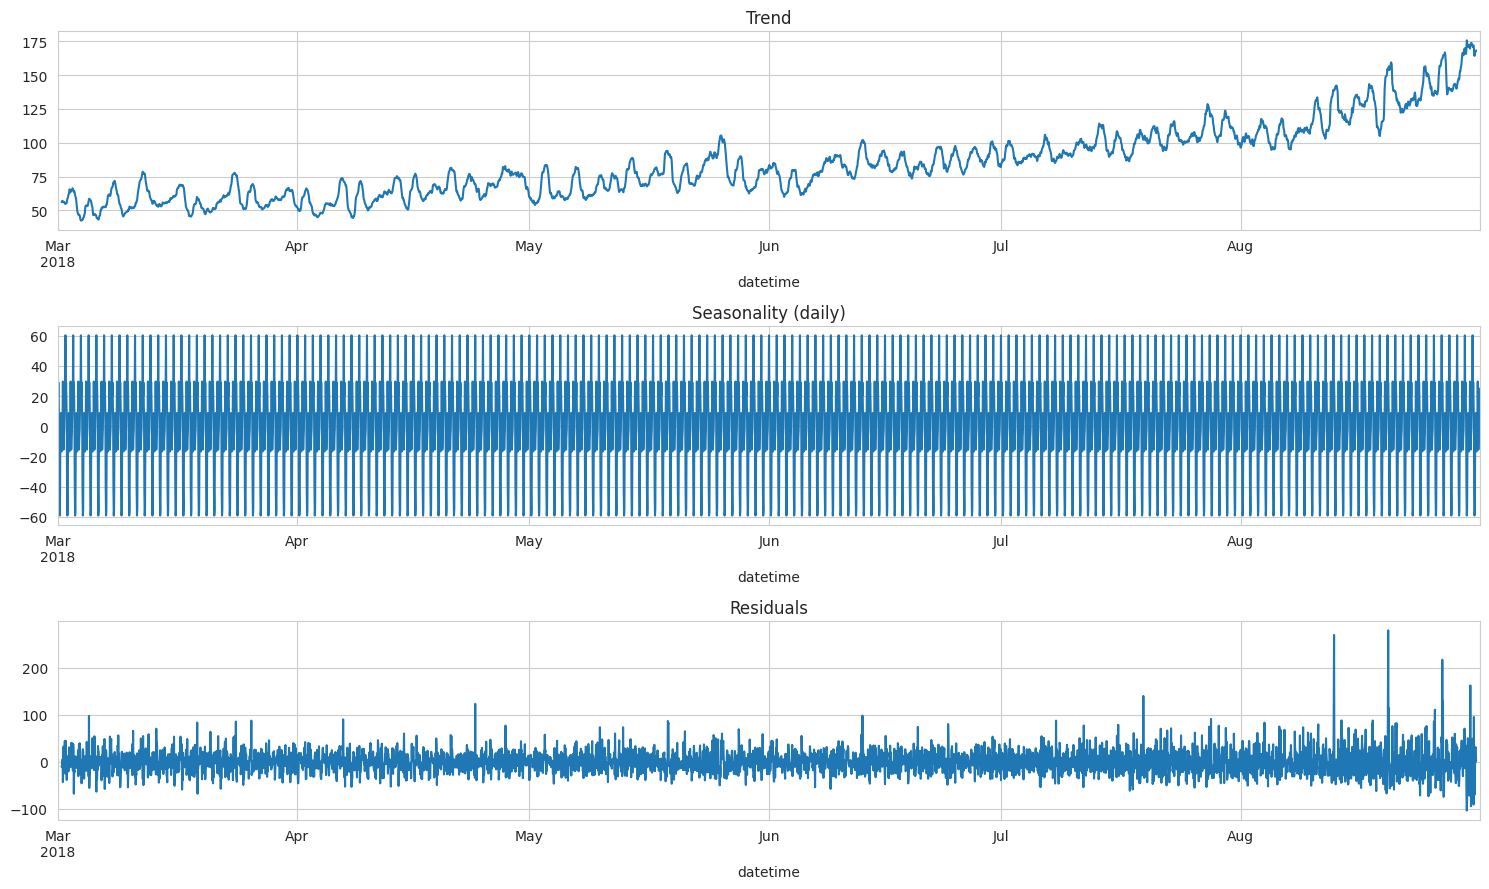

In [10]:
decomposed = seasonal_decompose(data['num_orders'], period=24)

fig, axes = plt.subplots(3, 1, figsize=(15, 9))
decomposed.trend.plot(ax=axes[0], title='Trend')
decomposed.seasonal.plot(ax=axes[1], title='Seasonality (daily)')
decomposed.resid.plot(ax=axes[2], title='Residuals')
plt.tight_layout()
plt.show()

The trend grows steadily over the whole period. To examine the shape of the daily seasonality more closely, let us display it over several days.

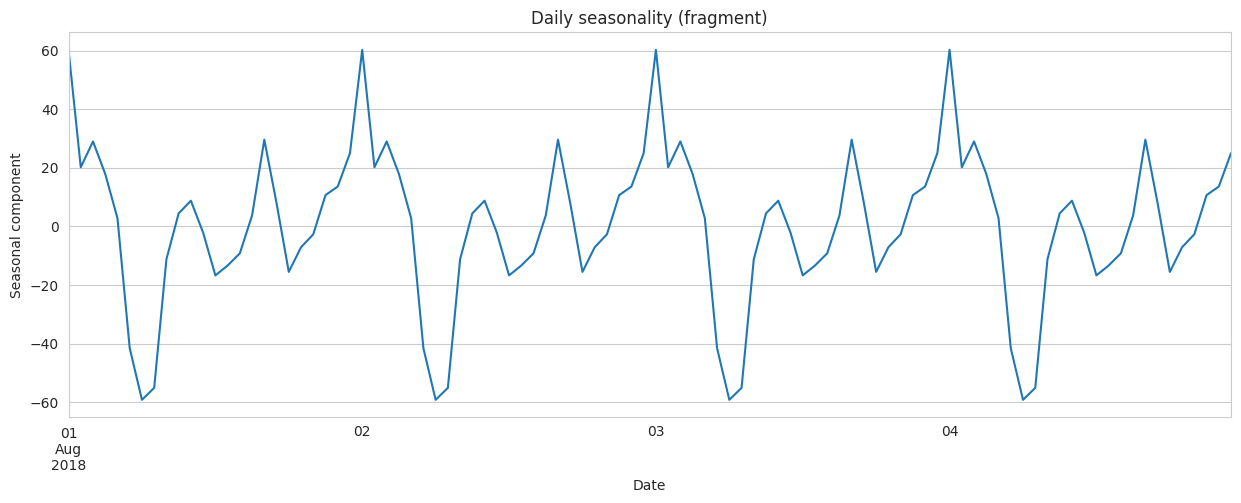

In [11]:
plt.figure(figsize=(15, 5))
decomposed.seasonal['2018-08-01':'2018-08-04'].plot()
plt.title('Daily seasonality (fragment)')
plt.xlabel('Date')
plt.ylabel('Seasonal component')
plt.show()

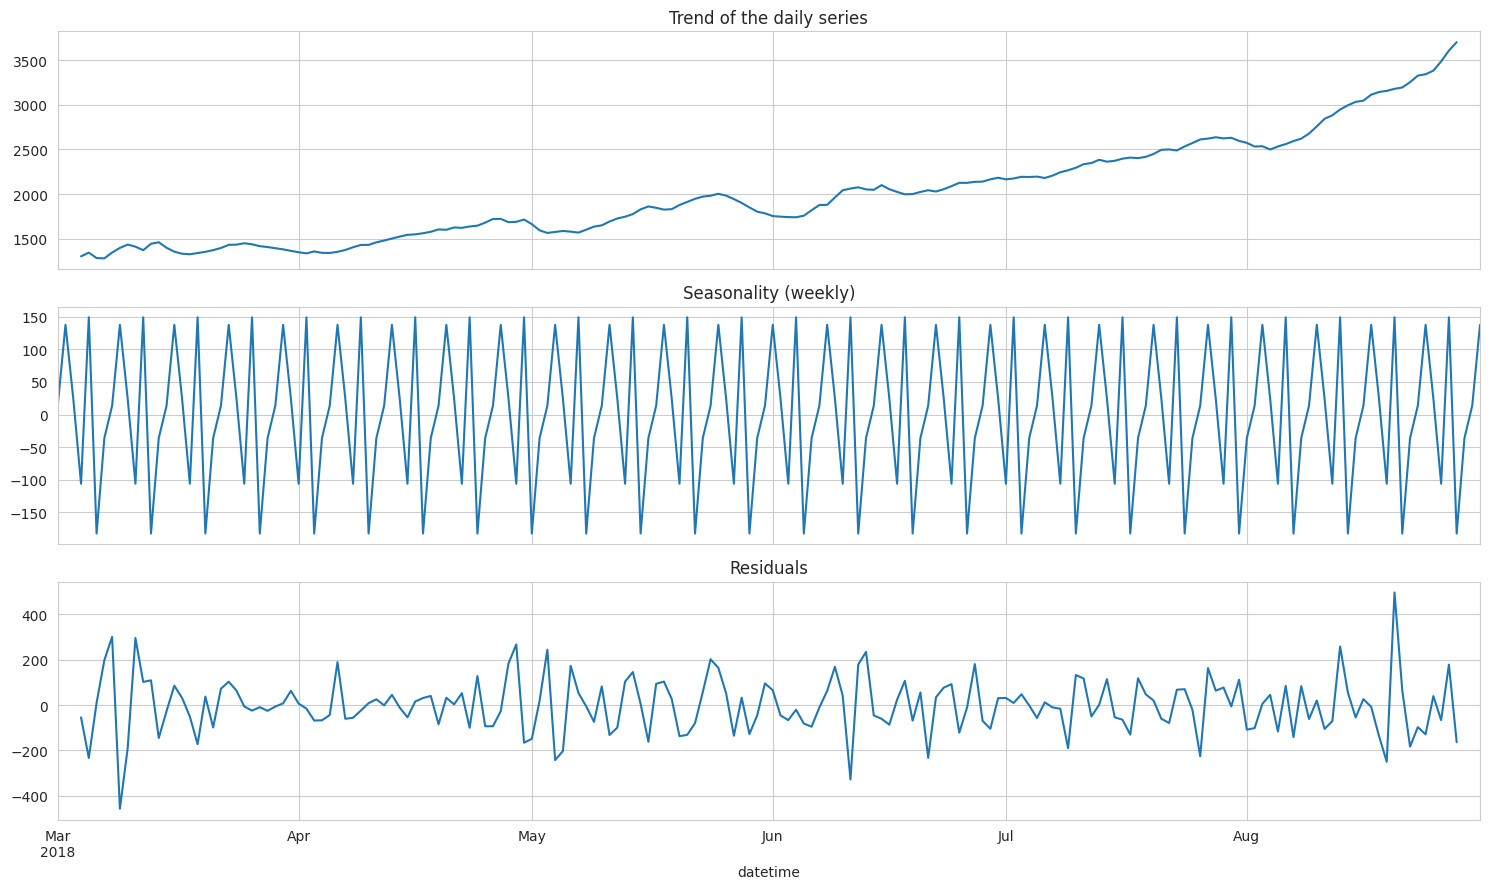

In [12]:
daily_orders = ts_hourly.resample('1D').sum()
decomposed_weekly = seasonal_decompose(daily_orders, period=7)

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
decomposed_weekly.trend.plot(ax=axes[0], title='Trend of the daily series')
decomposed_weekly.seasonal.plot(ax=axes[1], title='Seasonality (weekly)')
decomposed_weekly.resid.plot(ax=axes[2], title='Residuals')
for ax in axes:
    ax.grid(True)
plt.tight_layout()
plt.show()


A weekly pattern is visible on the daily series: the seasonal component regularly repeats peaks and troughs by day of the week. This means that it is useful to keep `dayofweek` among the features and to add lags up to the weekly period.


I decompose the daily series: first I sum the clean hourly series by days, then I specify period=7. On the hourly series seasonal_decompose picks out the shortest cycle — a day, and after resampling by days one can see the weekly seasonality.

Within a day there is a dip at night and a rise closer to midnight. The pattern repeats steadily from day to day. On the daily series a weekly seasonality is additionally noticeable: the values change systematically depending on the day of the week.

### EDA Conclusions

- The series is **non-stationary**: there is a pronounced upward trend.
- There is a stable **daily seasonality** and a noticeable **weekly** rhythm.
- This means that calendar features (`hour`, `dayofweek`), **lag features** up to the weekly period and a **rolling mean**, which will make it possible to take the trend and the seasonality into account, are useful for the model.


## Feature Engineering

Let us create a function that adds calendar features, lags and a rolling mean to the series. We compute the rolling mean on the shifted series, so as not to use the value of the current hour and not to allow leakage of the target feature.

In [13]:
def make_features(df, max_lag, rolling_size):
    df = df.copy()
    calendar_features = pd.DataFrame({
        'dayofweek': df.index.dayofweek,
        'hour': df.index.hour,
    }, index=df.index)
    lag_features = pd.concat(
        [df['num_orders'].shift(lag).rename(f'lag_{lag}') for lag in range(1, max_lag + 1)],
        axis=1,
    )
    rolling_mean = df['num_orders'].shift().rolling(rolling_size).mean().rename('rolling_mean')
    return pd.concat([df, calendar_features, lag_features, rolling_mean], axis=1)


We will take the lag depth and the rolling mean window equal to a week — 168 hours. Lags up to 168 will help the model take the daily and weekly seasonality into account, and the weekly rolling mean will describe the trend more smoothly. After creating the features we will drop the first rows with missing values from the lags.


In [14]:
data = make_features(data, MAX_LAG, ROLLING_SIZE)
data = data.dropna()
print('Shape after feature engineering:', data.shape)
data.head()

Shape after feature engineering: (4248, 172)


,num_orders,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_160,lag_161,lag_162,lag_163,lag_164,lag_165,lag_166,lag_167,lag_168,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,3,0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,54.226190
2018-03-08 01:00:00,78,3,1,143.0,94.0,127.0,108.0,76.0,50.0,99.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,54.339286
2018-03-08 02:00:00,65,3,2,78.0,143.0,94.0,127.0,108.0,76.0,50.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,54.297619
2018-03-08 03:00:00,68,3,3,65.0,78.0,143.0,94.0,127.0,108.0,76.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,54.261905
2018-03-08 04:00:00,60,3,4,68.0,65.0,78.0,143.0,94.0,127.0,108.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,54.273810


## Correlation Analysis

Let us assess the relationship of the features with the target and with each other. We use the **phik** coefficient — it captures non-linear dependencies as well and works with mixed feature types. Let us take the target feature, the rolling mean, several characteristic lags and the calendar features without `month`.


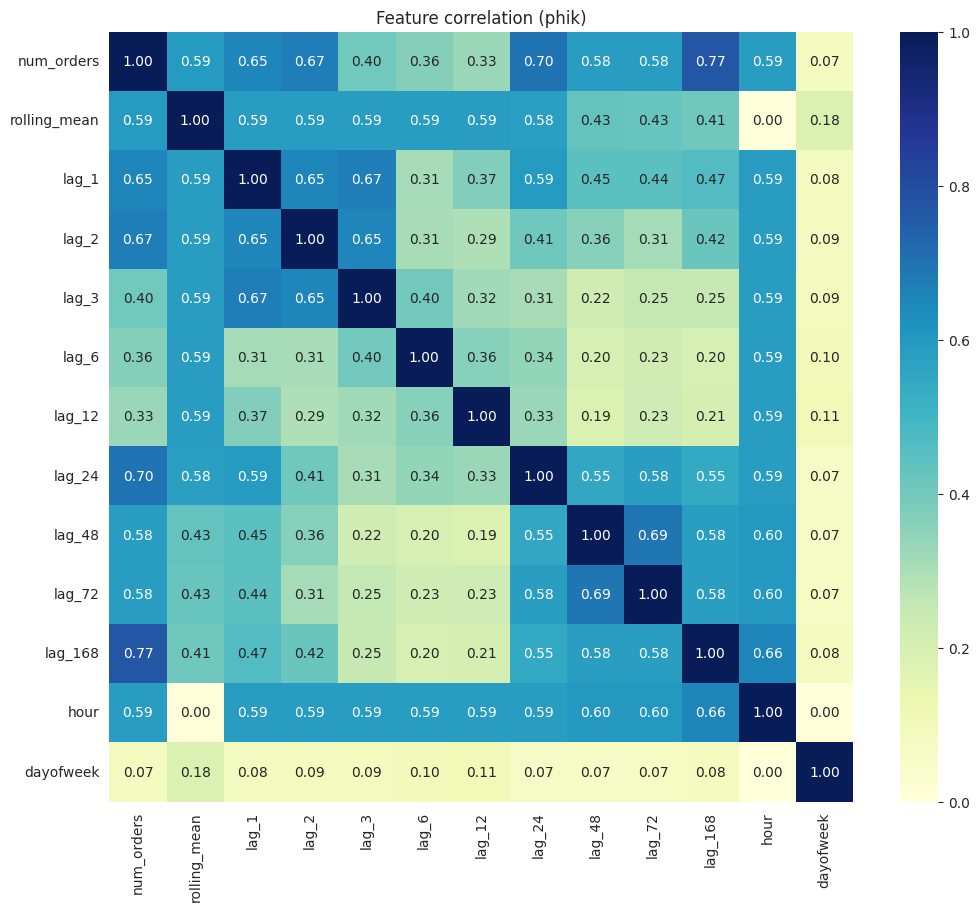

In [15]:
corr_features = ['num_orders', 'rolling_mean', 'lag_1', 'lag_2', 'lag_3',
                 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_72', 'lag_168',
                 'hour', 'dayofweek']
interval_cols = ['num_orders', 'rolling_mean', 'lag_1', 'lag_2', 'lag_3',
                 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_72', 'lag_168']

phi_k = data[corr_features].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 10))
ax = plt.axes()
sns.heatmap(phi_k, cmap='YlGnBu', annot=True, fmt='.2f')
ax.set_title('Feature correlation (phik)')
plt.show()


Separately, let us look at how strongly each feature is related to the target.

In [16]:
phi_k['num_orders'].sort_values(ascending=False)

num_orders      1.000000
lag_168         0.771505
lag_24          0.695922
lag_2           0.669751
lag_1           0.651113
rolling_mean    0.592183
hour            0.586500
lag_48          0.584892
lag_72          0.582689
lag_3           0.402665
lag_6           0.363714
lag_12          0.331333
dayofweek       0.074686
Name: num_orders, dtype: float64

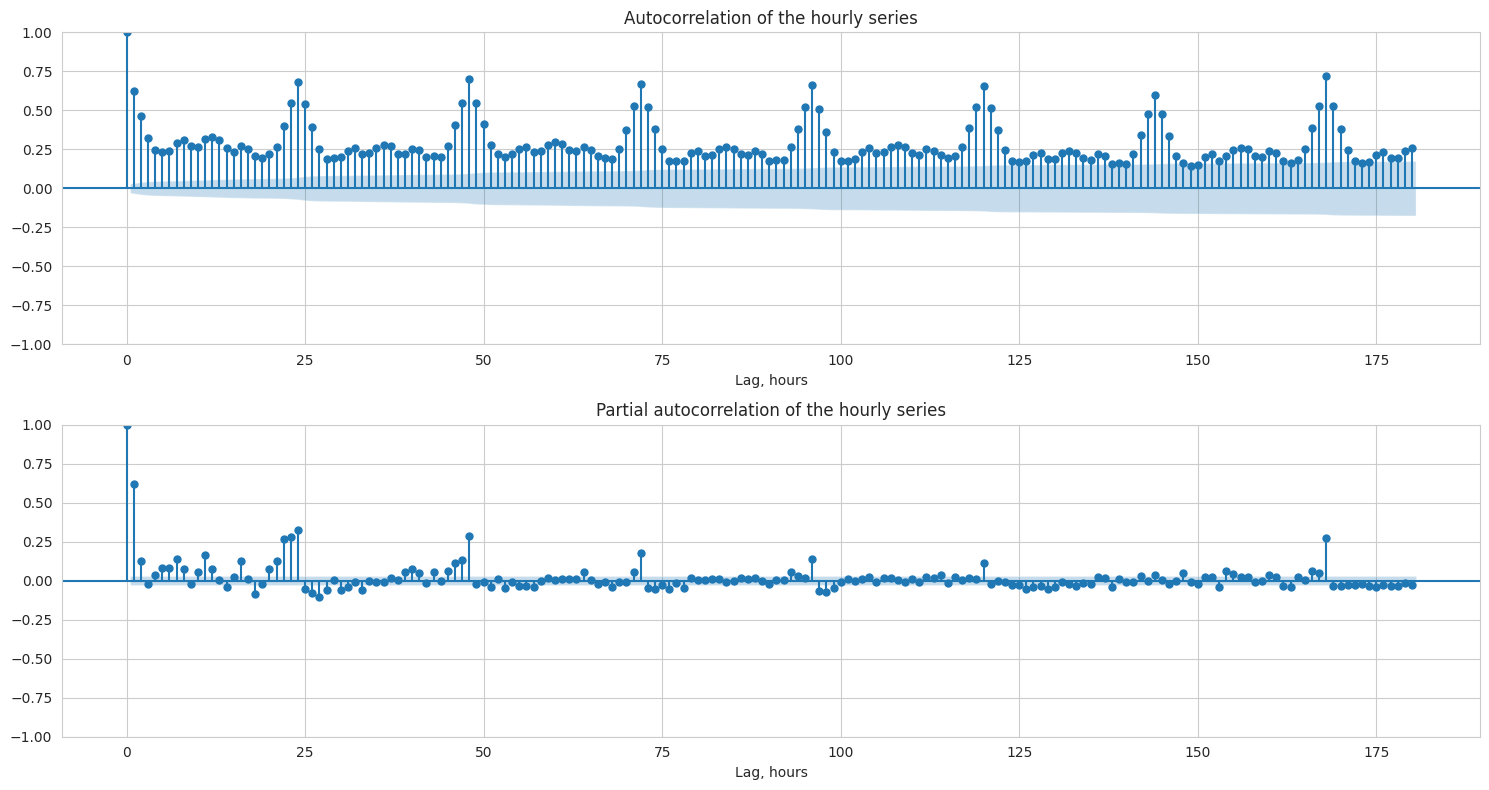

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
plot_acf(ts_hourly, lags=180, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation of the hourly series')
axes[0].set_xlabel('Lag, hours')
axes[0].grid(True)

plot_pacf(ts_hourly, lags=180, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial autocorrelation of the hourly series')
axes[1].set_xlabel('Lag, hours')
axes[1].grid(True)

plt.tight_layout()
plt.show()


The ACF and PACF plots on the clean hourly series show significant dependencies at lags of about 24 hours and 168 hours, which is why the weekly lag depth looks justified.

Conclusions of the correlation analysis:

- Among the lags, `lag_24` and `lag_168` stand out noticeably, which is consistent with the daily and weekly seasonality.
- The recent lags (`lag_1`, `lag_2`, `lag_3`) and `rolling_mean` are also related to the target: the series is inertial, and the rolling mean reflects the overall level of demand.
- We keep the features `hour` and `dayofweek` as calendar features of seasonality. `month` has been removed, because there is little data and the trend is already described by the lags and the rolling mean.
- The lags correlate strongly with each other, therefore among the linear models it is reasonable to take regularized ones — ridge regression and Lasso.


## Training Models

Let us split the data **without shuffling** — for a time series the order of the observations matters. First we separate the test set (the last 10%), then from the remaining data we set aside the validation set (the last 20%) for hyperparameter search.

In [18]:
train_valid, test = train_test_split(data, shuffle=False, test_size=TEST_SIZE)
train, valid = train_test_split(train_valid, shuffle=False, test_size=VALID_SIZE)

features_train, target_train = train.drop('num_orders', axis=1), train['num_orders']
features_valid, target_valid = valid.drop('num_orders', axis=1), valid['num_orders']
features_test, target_test = test.drop('num_orders', axis=1), test['num_orders']
features_tv, target_tv = train_valid.drop('num_orders', axis=1), train_valid['num_orders']

print('Train:     ', features_train.shape, '|', train.index.min(), '—', train.index.max())
print('Validation:', features_valid.shape, '|', valid.index.min(), '—', valid.index.max())
print('Test:      ', features_test.shape, '|', test.index.min(), '—', test.index.max())

Train:      (3058, 171) | 2018-03-08 00:00:00 — 2018-07-13 09:00:00
Validation: (765, 171) | 2018-07-13 10:00:00 — 2018-08-14 06:00:00
Test:       (425, 171) | 2018-08-14 07:00:00 — 2018-08-31 23:00:00


Let us set up helper functions and feature lists. For the linear models I will encode `hour` and `dayofweek` as categorical via `OneHotEncoder` inside a `Pipeline` and a `ColumnTransformer`. The lags and `rolling_mean` are scaled there as well, so the scaler is fitted only on the training part.


In [19]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

categorical_features = ['hour', 'dayofweek']
numeric_features = [col for col in features_train.columns if col not in categorical_features]


def make_ohe_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ],
        remainder='drop',
    )


def make_linear_pipeline(model):
    return Pipeline([
        ('preprocessor', make_ohe_preprocessor()),
        ('model', model),
    ])


def fit_predict(model, X_fit, y_fit, X_eval):
    model.fit(X_fit, y_fit)
    return model.predict(X_eval)


As **baseline models** let us take several naive forecasts: the previous hour (`lag_1`), the same hour of the previous day (`lag_24`) and the same hour of the previous week (`lag_168`). I compute all the baselines on the same test set as the final model.


In [20]:
baseline_rmse_lag1 = rmse(target_test, features_test['lag_1'])
baseline_rmse_lag24 = rmse(target_test, features_test['lag_24'])
baseline_rmse_lag168 = rmse(target_test, features_test['lag_168'])

baseline_results = pd.DataFrame({
    'Baseline': ['lag_1: previous hour', 'lag_24: same hour yesterday', 'lag_168: same hour a week ago'],
    'RMSE_test': [baseline_rmse_lag1, baseline_rmse_lag24, baseline_rmse_lag168],
}).sort_values('RMSE_test').reset_index(drop=True)

baseline_results


,Baseline,RMSE_test
0,lag_168: same hour a week ago,39.286938
1,lag_24: same hour yesterday,55.862247
2,lag_1: previous hour,58.819725


Let us train several classical regression models and tune their hyperparameters on the validation set. For Ridge and Lasso the calendar features are encoded via OHE in a pipeline, while the trees and the ensembles receive the features in their original form. We will keep the grids of the heavy models compact, so that the notebook executes in a reasonable time.


In [21]:
models = {
    'Ridge': (
        make_linear_pipeline(Ridge(random_state=RANDOM_STATE)),
        {'model__alpha': [0.1, 1, 10, 100]},
    ),
    'Lasso': (
        make_linear_pipeline(Lasso(random_state=RANDOM_STATE, max_iter=10000)),
        {'model__alpha': [0.001, 0.01, 0.1, 1]},
    ),
    'DecisionTree': (
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {'max_depth': [4, 6, 8, 10]},
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [8, 12], 'min_samples_leaf': [3]},
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05]},
    ),
}


In [22]:
valid_rmse = {}
best_params = {}

for name, (estimator, param_grid) in models.items():
    best_rmse, best_p = float('inf'), None
    for params in ParameterGrid(param_grid):
        candidate = clone(estimator).set_params(**params)
        pred = fit_predict(candidate, features_train, target_train, features_valid)
        score = rmse(target_valid, pred)
        if score < best_rmse:
            best_rmse, best_p = score, params
    valid_rmse[name] = best_rmse
    best_params[name] = best_p
    print('{:16s} RMSE(valid)={:.2f}  params={}'.format(name, best_rmse, best_p))


Ridge            RMSE(valid)=27.18  params={'model__alpha': 100}


Lasso            RMSE(valid)=27.05  params={'model__alpha': 0.1}


DecisionTree     RMSE(valid)=33.16  params={'max_depth': 6}


RandomForest     RMSE(valid)=29.48  params={'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 200}


GradientBoosting RMSE(valid)=28.44  params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}


Let us bring the validation results together into a table and compare the models.

In [23]:
results = pd.DataFrame({'RMSE_valid': valid_rmse}).sort_values('RMSE_valid')
results

,RMSE_valid
Lasso,27.050043
Ridge,27.182038
GradientBoosting,28.440065
RandomForest,29.484205
DecisionTree,33.156694


Let us choose the model with the lowest RMSE on the validation set.

In [24]:
best_name = results.index[0]
best_model = clone(models[best_name][0]).set_params(**best_params[best_name])
print('Best model by validation:', best_name, '|', best_params[best_name])

Best model by validation: Lasso | {'model__alpha': 0.1}


## Comparison of Feature Encoding Methods

Separately, I will compare the encoding methods for `hour` and `dayofweek` on one and the same linear Ridge model with a fixed `alpha=1.0`. In all the variants the lags and `rolling_mean` are scaled identically. For the test estimate I train each pipeline on the union of train+valid, and then compute RMSE on the test set.


In [25]:
def make_cyclical_transformer(period):
    def transform(values):
        values = np.asarray(values, dtype=float)
        feature = values[:, 0]
        return np.column_stack([
            np.sin(2 * np.pi * feature / period),
            np.cos(2 * np.pi * feature / period),
        ])

    return FunctionTransformer(transform, validate=False)


def make_encoding_preprocessor(encoding):
    if encoding == 'OHE':
        categorical_transformers = [
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ]
    elif encoding == 'TargetEncoder':
        categorical_transformers = [
            ('cat', Pipeline([
                ('encoder', TargetEncoder(random_state=RANDOM_STATE)),
                ('scaler', StandardScaler()),
            ]), categorical_features),
        ]
    elif encoding == 'Trigonometric':
        categorical_transformers = [
            ('hour_trig', Pipeline([
                ('encoder', make_cyclical_transformer(24)),
                ('scaler', StandardScaler()),
            ]), ['hour']),
            ('day_trig', Pipeline([
                ('encoder', make_cyclical_transformer(7)),
                ('scaler', StandardScaler()),
            ]), ['dayofweek']),
        ]
    elif encoding == 'Splines':
        categorical_transformers = [
            ('hour_spline', Pipeline([
                ('encoder', SplineTransformer(n_knots=24, degree=3, extrapolation='periodic', include_bias=False)),
                ('scaler', StandardScaler()),
            ]), ['hour']),
            ('day_spline', Pipeline([
                ('encoder', SplineTransformer(n_knots=7, degree=3, extrapolation='periodic', include_bias=False)),
                ('scaler', StandardScaler()),
            ]), ['dayofweek']),
        ]
    elif encoding == 'Polynomial':
        categorical_transformers = [
            ('cat_poly', Pipeline([
                ('encoder', PolynomialFeatures(degree=2, include_bias=False)),
                ('scaler', StandardScaler()),
            ]), categorical_features),
        ]
    else:
        raise ValueError('Unknown encoding')

    return ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric_features), *categorical_transformers],
        remainder='drop',
    )


encoding_rows = []
for encoding in ['OHE', 'TargetEncoder', 'Trigonometric', 'Splines', 'Polynomial']:
    model = Pipeline([
        ('preprocessor', make_encoding_preprocessor(encoding)),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ])
    start = time.perf_counter()
    model.fit(features_tv, target_tv)
    fit_time = time.perf_counter() - start
    pred = model.predict(features_test)
    encoding_rows.append({
        'Encoding': encoding,
        'RMSE_test': rmse(target_test, pred),
        'Fit time, s': fit_time,
    })

encoding_results = pd.DataFrame(encoding_rows).sort_values('RMSE_test').reset_index(drop=True)
encoding_results


,Encoding,RMSE_test,"Fit time, s"
0,TargetEncoder,33.749263,0.293004
1,OHE,33.881419,0.028291
2,Splines,33.934121,0.029391
3,Polynomial,34.094819,0.019578
4,Trigonometric,34.170926,0.023674


`TargetEncoder` worked best on this task: **RMSE_test ≈ 33.75**. OHE was almost as good (**≈ 33.88**), because `hour` and `dayofweek` really do behave as categorical features of seasonality. The trigonometric encoding, the splines and the polynomial features also give close quality, but here they are slightly weaker: apparently, for a linear model it is more useful to encode the average demand by the categories of hour and day of the week directly.


## Testing the Best Model

Let us train the selected model on the combined training and validation set and evaluate it on the test set. This way the final training uses all the data that is available before the test period.


In [26]:
test_pred = fit_predict(best_model, features_tv, target_tv, features_test)
test_rmse = rmse(target_test, test_pred)

print('Model:                           ', best_name)
print('RMSE on test:                    {:.2f}'.format(test_rmse))
print('RMSE of the best naive forecast: {:.2f}'.format(baseline_results['RMSE_test'].min()))
print('Condition RMSE <= {} satisfied:'.format(MAX_RMSE), test_rmse <= MAX_RMSE)


Model:                            Lasso
RMSE on test:                    34.05
RMSE of the best naive forecast: 39.29
Condition RMSE <= 48 satisfied: True


Let us compare the forecast with the actual values on the test set.

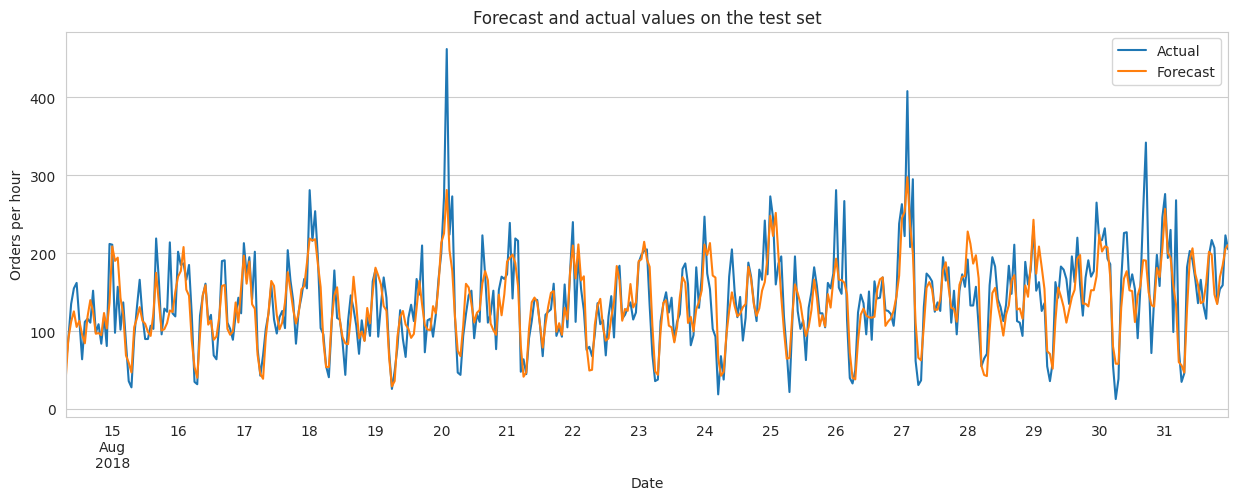

In [27]:
plt.figure(figsize=(15, 5))
target_test.plot(label='Actual')
pd.Series(test_pred, index=target_test.index).plot(label='Forecast')
plt.title('Forecast and actual values on the test set')
plt.xlabel('Date')
plt.ylabel('Orders per hour')
plt.legend()
plt.show()

The final forecast follows the main dynamics of the test period and reacts to the daily peaks. When assessing the quality it is important to compare it not only with the threshold of the task, but also with the strong weekly baseline `lag_168`.


## Overall Conclusion

- The source data on taxi orders (March–August 2018, step of 10 minutes) was resampled by one hour — we obtained 4416 observations with no missing values.
- The analysis showed an upward trend, a stable daily seasonality and a weekly pattern. Daily and weekly rolling means were added to the overall chart, and the weekly seasonality was additionally checked by a decomposition of the daily series.
- The features `hour`, `dayofweek`, lags up to 168 hours and the weekly `rolling_mean` were added to the features. The feature `month` was removed, because there is data for only six months, and the trend is already taken into account by the lags and the rolling mean.
- Naive baselines were checked on the test set: `lag_1` gave **RMSE ≈ 58.82**, `lag_24` — **≈ 55.86**, `lag_168` — **≈ 39.29**. The strongest naive forecast is the same hour of the previous week.
- For the linear models `hour` and `dayofweek` were encoded as categorical via OHE inside a `Pipeline` and a `ColumnTransformer`. In the separate comparison of encodings for Ridge, `TargetEncoder` worked best (**RMSE_test ≈ 33.75**), OHE was at almost the same level (**≈ 33.88**).
- On the validation set the best one was `Lasso` with `alpha=0.1`. Before the test I trained it on the union of train+valid, on the test I obtained **RMSE ≈ 34.05**.
- The goal of the project has been achieved: the final error is below the threshold of **48** and better than the strong weekly baseline `lag_168` (**34.05 versus 39.29**).
